In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import torch
import torch.nn as nn
import h5py
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm


warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.dpi'] = 200 # plots quality


path='/content/drive/Shareddrives/XAI Project Shared Drive'

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [29]:
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [30]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def aggregate_diagnostic(y_dict):
    new_dict = {}

    for sc in superclasses:
        new_dict[sc]=0

    for key, val in y_dict.items():
        if key in agg_df.index:
            sc = agg_df.loc[key]['diagnostic_class']
            new_dict[sc]=max(new_dict[sc], val/100)

    lst = []
    for sc in superclasses:
        if new_dict[sc] >= 0.5:
            lst.append(1)
        else:
            lst.append(0)
    return lst

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)

In [31]:
Y = np.array(df_ptbxl['diagnostic_superclass'].to_list())

train_mask = df_ptbxl['strat_fold'] <= 8
val_mask = df_ptbxl['strat_fold'] == 9
test_mask = df_ptbxl['strat_fold'] == 10

X_train, y_train = X[train_mask], Y[train_mask]
X_val, y_val     = X[val_mask], Y[val_mask]
X_test, y_test   = X[test_mask], Y[test_mask]

# Model 1: 2D CNN + STFT Spectrograms

In [6]:
import torch
import torch.nn as nn
from torch import optim

class CNN(nn.Module):
    def __init__(self, in_channels, num_classes, hidden_size=64):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=3, kernel_size=4, padding='same')
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=13, kernel_size=2, padding='same')
        self.conv3 = nn.Conv2d(in_channels=13, out_channels=1, kernel_size=2, padding='same')

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.5)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(135, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        # first layer
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # second layer
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # third layer
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        # final layers
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
#        x = self.sigmoid(x) BCEWithLogitsLoss

        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
cnn = CNN(in_channels=1, num_classes=5).to(device)
print(cnn)

cuda
CNN(
  (conv1): Conv2d(1, 3, kernel_size=(4, 4), stride=(1, 1), padding=same)
  (conv2): Conv2d(3, 13, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (conv3): Conv2d(13, 1, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=135, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)


In [7]:
# test
cnn.forward(torch.zeros(1, 1, 45, 219).to(device))

tensor([[-0.0968, -0.1209,  0.0795,  0.0904,  0.0391]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [33]:
import h5py
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
class ECGH5Dataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path

        with h5py.File(self.file_path, 'r') as f:
            self.length = f['features'].shape[0]

        self.file = None

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.file_path, 'r')

        x = self.file['features'][idx, [1]]
        y = self.file['labels'][idx]

        return torch.from_numpy(x).float(), torch.from_numpy(y).float()

train_dataset = ECGH5Dataset(f'{path}/spectrograms/train.h5')
val_dataset = ECGH5Dataset(f'{path}/spectrograms/val.h5')
test_dataset = ECGH5Dataset(f'{path}/spectrograms/test.h5')

kwargs = {'batch_size': 128, 'num_workers': 4, 'pin_memory': True, 'prefetch_factor': 2}

targets = torch.stack([sample[1] for sample in train_dataset])

class_sums = targets.sum(dim=0)
class_weights = 1.0 / (class_sums + 1e-8)

sample_weights = (targets * class_weights).sum(dim=1)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


train_loader = DataLoader(train_dataset, sampler=sampler, **kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **kwargs)

In [13]:
train_dataset.__getitem__(0)[0].shape

torch.Size([1, 45, 219])

In [14]:
# model training
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(cnn.parameters(), lr=0.001, weight_decay=0.03)

In [ ]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import numpy as np

num_epochs = 10
criterion = nn.BCEWithLogitsLoss()

# Initialize model and optimizer once
cnn = CNN(in_channels=1, num_classes=5).to(device)
optimizer = optim.AdamW(cnn.parameters(), lr=0.001, weight_decay=0.03)

train_losses, val_losses, val_aucs = [], [], []

epoch_bar = tqdm(range(num_epochs), desc='Training Epochs')
for epoch in epoch_bar:

    # --- Training Phase ---
    cnn.train()
    tr_loss = 0.0
    for data, targets in train_loader:
        data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = cnn(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item()

    tr_loss /= len(train_loader)

    # --- Validation Phase ---
    cnn.eval()
    va_loss = 0.0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            outputs = cnn(data)
            va_loss += criterion(outputs, targets).item()

            # Store probabilities and true labels for AUC calculation
            probs = torch.sigmoid(outputs)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    va_loss /= len(val_loader)

    # Concatenate batches and compute multi-label AUC
    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    try:
        val_auc = roc_auc_score(all_targets, all_preds, average='macro')
    except ValueError:
        val_auc = float('nan') # Failsafe if a class happens to have only one target type in a batch

    # --- Logging ---
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    val_aucs.append(val_auc)

    epoch_bar.set_postfix(
        train_loss=f'{tr_loss:.4f}',
        val_loss=f'{va_loss:.4f}',
        val_auc=f'{val_auc:.4f}'
    )

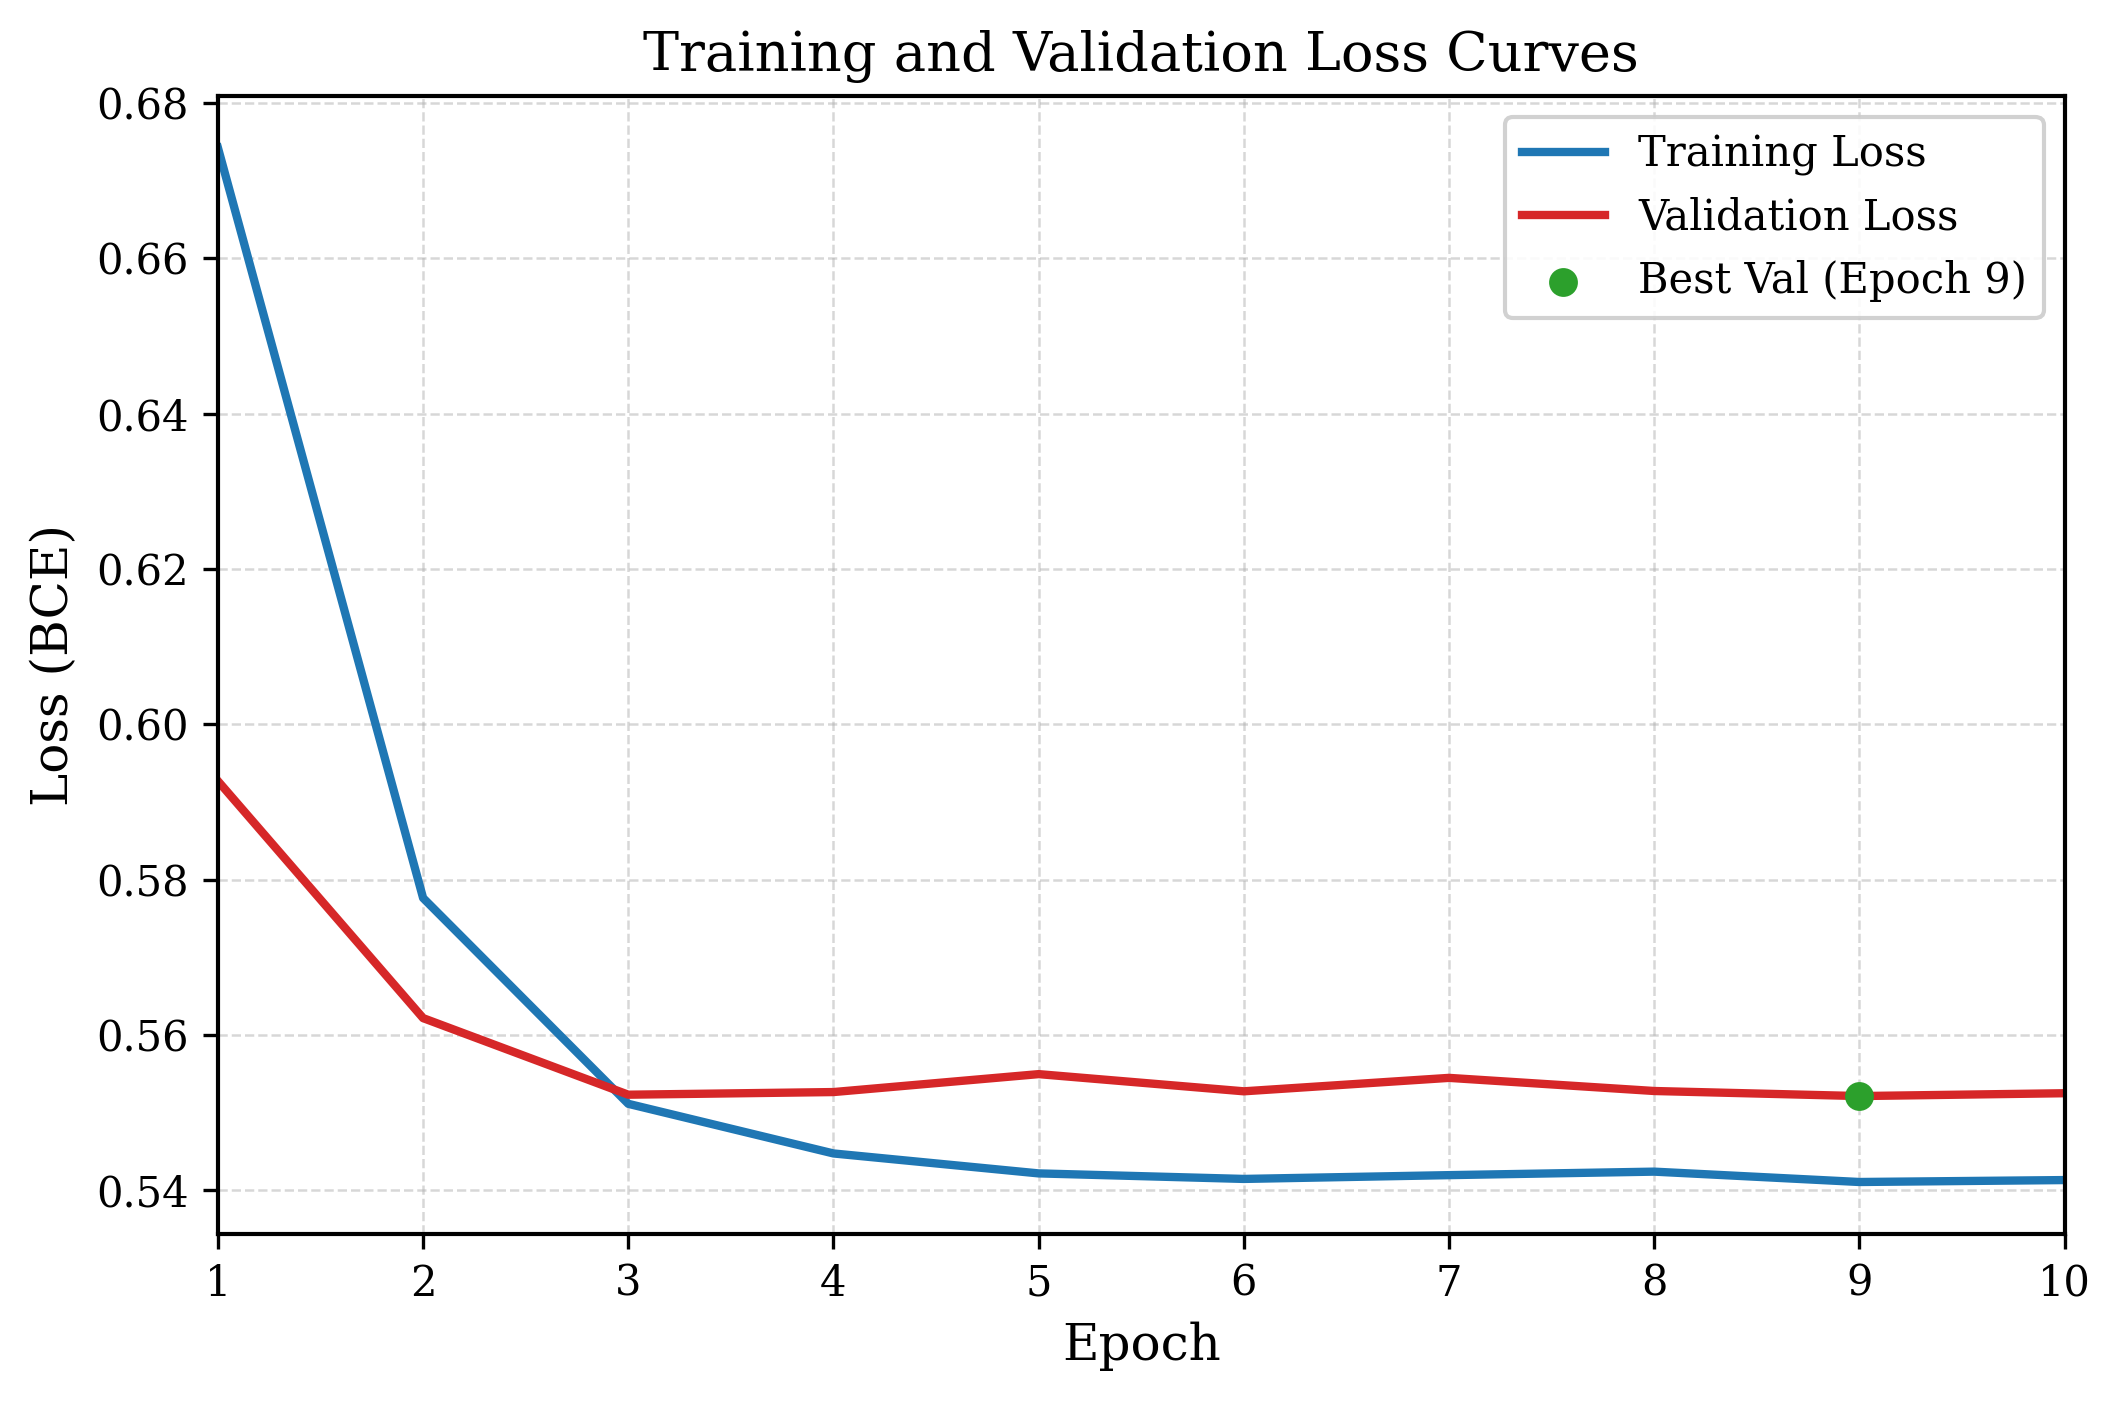

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Publication-style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs = np.arange(1, len(train_losses) + 1)
train_arr = np.asarray(train_losses, dtype=float)
val_arr = np.asarray(val_losses, dtype=float)

if len(train_arr) != len(val_arr):
    raise ValueError(f"Length mismatch: train_loss={len(train_arr)}, val_losses={len(val_arr)}")

best_epoch = int(np.argmin(val_arr)) + 1
best_val = float(np.min(val_arr))

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=300)

ax.plot(
    epochs,
    train_arr,
    color="#1f77b4",
    linewidth=2.0,
    label="Training Loss",
)
ax.plot(
    epochs,
    val_arr,
    color="#d62728",
    linewidth=2.0,
    label="Validation Loss",
)

ax.scatter(
    [best_epoch],
    [best_val],
    color="#2ca02c",
    s=35,
    zorder=5,
    label=f"Best Val (Epoch {best_epoch})",
)

ax.set_title("Training and Validation Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (BCE)")
ax.set_xlim(1, len(epochs))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=True, facecolor="white", framealpha=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

fig.tight_layout()
# fig.savefig("loss_curves_3_BCE_AdamW-2.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
x, y = train_dataset.__getitem__(618)

x = x.reshape(1, *x.shape).to(device)

y_pred = cnn.forward(x).cpu().detach().numpy()
# apply sigmoid
y_pred = 1 / (1 + np.exp(-y_pred))

y_true = y.numpy()
print(np.round(y_pred, 1), '\n', y_true)

[[0.4 0.2 0.2 0.2 0.1]] 
 [1. 0. 0. 0. 0.]


# Explanations

In [19]:
!pip install -q torch numpy pandas scikit-learn shap lime captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 26.4 MB/s eta 0:00:00


  0%|          | 0/100 [00:00<?, ?it/s]

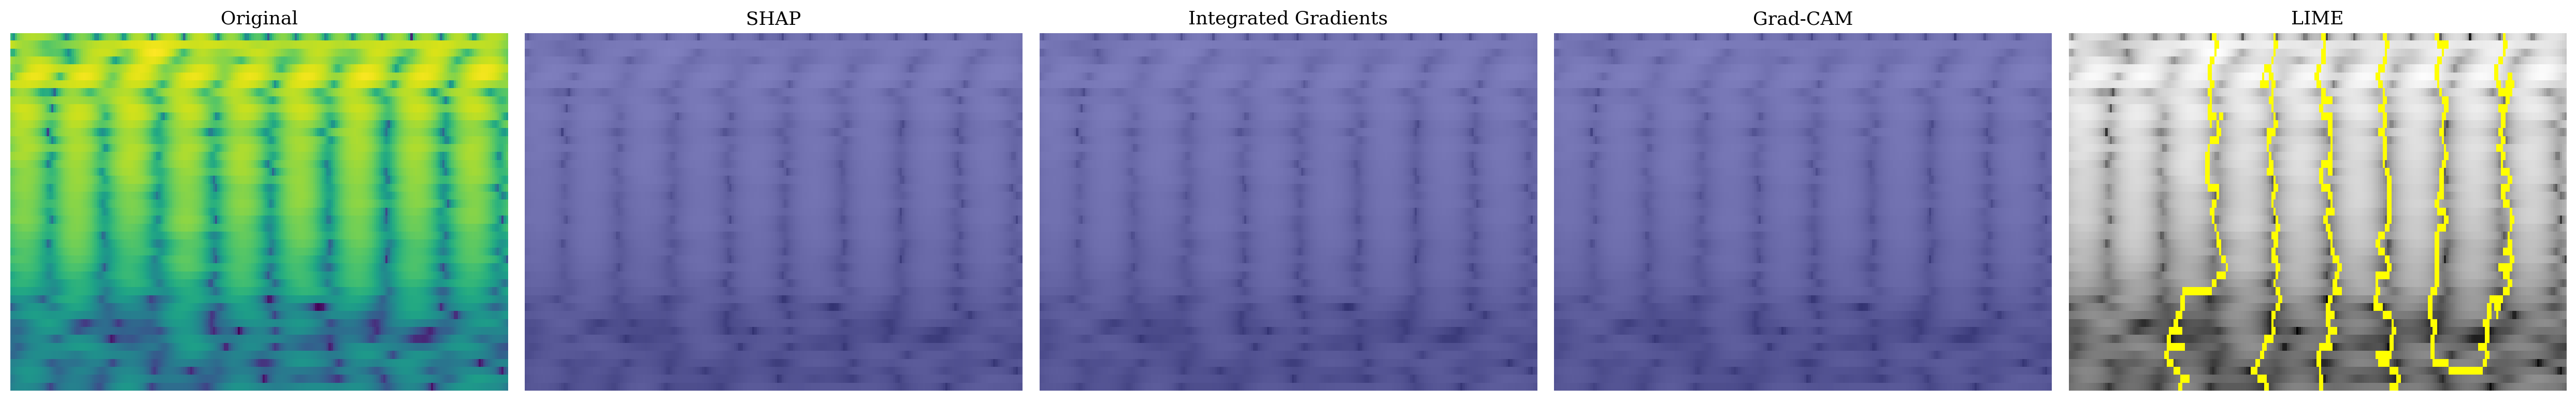

In [44]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import shap
from captum.attr import IntegratedGradients, LayerGradCam
from lime import lime_image
from skimage.segmentation import mark_boundaries
from scipy.ndimage import gaussian_filter

def prep_heatmap(hm_data):
    """Safely extracts, normalizes, and smooths gradient maps."""
    hm = np.squeeze(np.array(hm_data))
    hm = np.nan_to_num(hm)
    hm = np.abs(hm) # We care about magnitude of importance

    # If the map isn't completely dead, stretch it to [0, 1] for uniform alpha blending
    if hm.max() > 0:
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)

    # Slight blur makes sparse PyTorch pixel gradients visible as cohesive regions
    return gaussian_filter(hm, sigma=1.0)

def explain_and_plot(model, dataset, device):
    model.eval()
    torch.backends.cudnn.enabled = False

    # 1. Setup & Data Extraction
    raw_img, target = dataset[0]
    norm_img = (raw_img - raw_img.min()) / (raw_img.max() - raw_img.min() + 1e-8)

    img = norm_img.unsqueeze(0).to(device)
    img.requires_grad_()
    tc = torch.argmax(target).item()
    img_np = img[0, 0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 5, figsize=(25, 4))
    for ax in axes: ax.axis('off')

    axes[0].imshow(img_np, cmap='viridis', aspect='auto')
    axes[0].set_title("Original")

    # 2. SHAP
    bg = torch.stack([dataset[i][0] for i in range(1, 21)])
    bg = ((bg - bg.amin()) / (bg.amax() - bg.amin() + 1e-8)).to(device) # Normalize background too

    sv = shap.GradientExplainer(model, bg).shap_values(img)
    sv_map = sv[tc] if isinstance(sv, list) else sv[..., tc] if sv.shape[-1] == model.fc2.out_features else sv[:, tc, ...]

    axes[1].imshow(img_np, cmap='gray', aspect='auto', alpha=0.6)
    axes[1].imshow(prep_heatmap(sv_map), cmap='jet', alpha=0.5, aspect='auto')
    axes[1].set_title("SHAP")

    # 3. Integrated Gradients
    ig_attr = IntegratedGradients(model).attribute(img, target=tc)

    axes[2].imshow(img_np, cmap='gray', aspect='auto', alpha=0.6)
    axes[2].imshow(prep_heatmap(ig_attr[0, 0].cpu().detach()), cmap='jet', alpha=0.5, aspect='auto')
    axes[2].set_title("Integrated Gradients")

    # 4. Grad-CAM
    gc_attr = LayerGradCam(model, model.conv2).attribute(img, target=tc, relu_attributions=False)
    gc_up = F.interpolate(gc_attr, size=img.shape[2:], mode='bilinear', align_corners=False)

    axes[3].imshow(img_np, cmap='gray', aspect='auto', alpha=0.6)
    axes[3].imshow(prep_heatmap(gc_up[0, 0].cpu().detach()), cmap='jet', alpha=0.5, aspect='auto')
    axes[3].set_title("Grad-CAM")

    # 5. LIME
    def lime_pred(imgs):
        tnsr = torch.tensor(imgs).permute(0, 3, 1, 2)[:, [0]].float().to(device)
        with torch.no_grad():
            return torch.softmax(model(tnsr), dim=1).cpu().numpy()

    lime_exp = lime_image.LimeImageExplainer().explain_instance(
        np.repeat(img_np[..., None], 3, axis=-1).astype(np.float64),
        lime_pred, top_labels=1, hide_color=0, num_samples=100
    )
    temp, mask = lime_exp.get_image_and_mask(lime_exp.top_labels[0], positive_only=True, hide_rest=False)
    axes[4].imshow(mark_boundaries(temp, mask), aspect='auto')
    axes[4].set_title("LIME")

    plt.tight_layout()
    plt.show()

# Execution
explain_and_plot(cnn, test_dataset, device)